Columns in dataset:
Index(['time', 'x', 'y', 'z', 'Fx', 'Fy', 'Fz'], dtype='str')

Position columns: ['x', 'y', 'z']
Force columns: ['Fx', 'Fy', 'Fz']


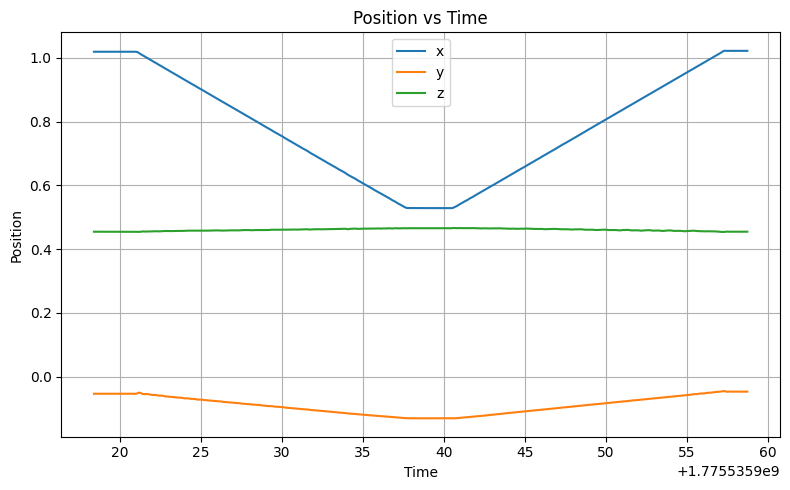

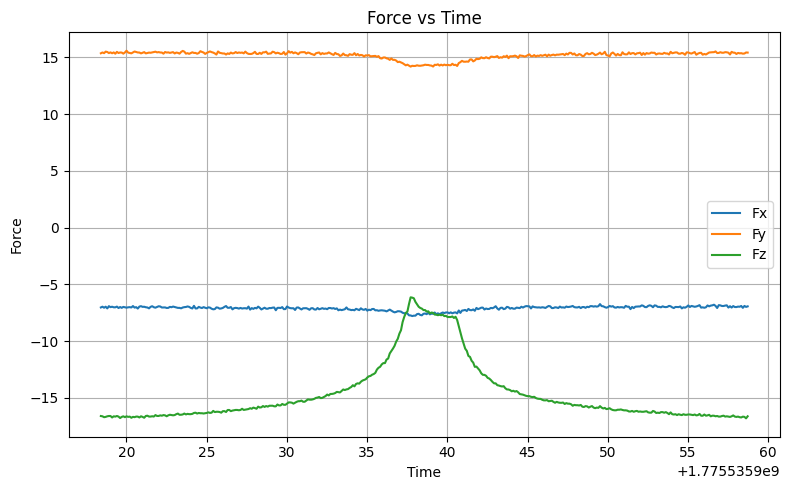

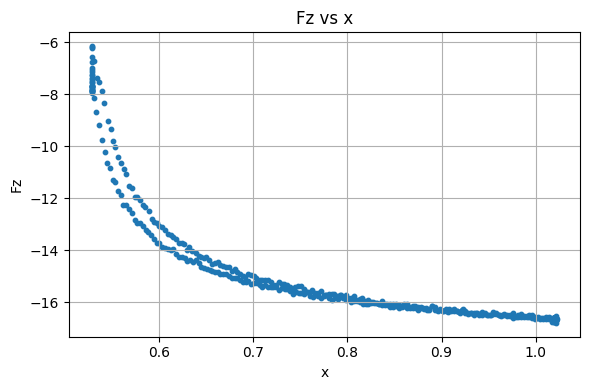

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
file_path = "plastic_3_turns.csv"
# file_path = "steel_5_turns.csv"
data = pd.read_csv(file_path)

# -----------------------------
# Inspect columns
# -----------------------------
print("Columns in dataset:")
print(data.columns)
# -----------------------------
# Position & force columns
# -----------------------------
time = data["time"]
pos_cols = ["x", "y", "z"]
force_cols = ["Fx", "Fy", "Fz"]

print("\nPosition columns:", pos_cols)
print("Force columns:", force_cols)

# -----------------------------
# Plot positions vs time
# -----------------------------
plt.figure(figsize=(8,5))
for col in pos_cols:
    plt.plot(time, data[col], label=col)

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Position vs Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot forces vs time
# -----------------------------
plt.figure(figsize=(8,5))
for col in force_cols:
    plt.plot(time, data[col], label=col)

plt.xlabel("Time")
plt.ylabel("Force")
plt.title("Force vs Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot force Fz vs displacement x
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(data["x"], data["Fz"], s=10)
plt.xlabel("x")
plt.ylabel("Fz")
plt.title("Fz vs x")
plt.grid()
plt.tight_layout()
plt.show()

### displacement is in x direction, force is in Fz direction

Data loaded. Number of samples: 404
Negative runs: [(21, 198), (200, 201), (207, 211), (394, 394), (398, 402)]
Positive runs: [(0, 4), (216, 393)]
Pulling phase: start = 21, end = 199
Pushing phase: start = 216, end = 394


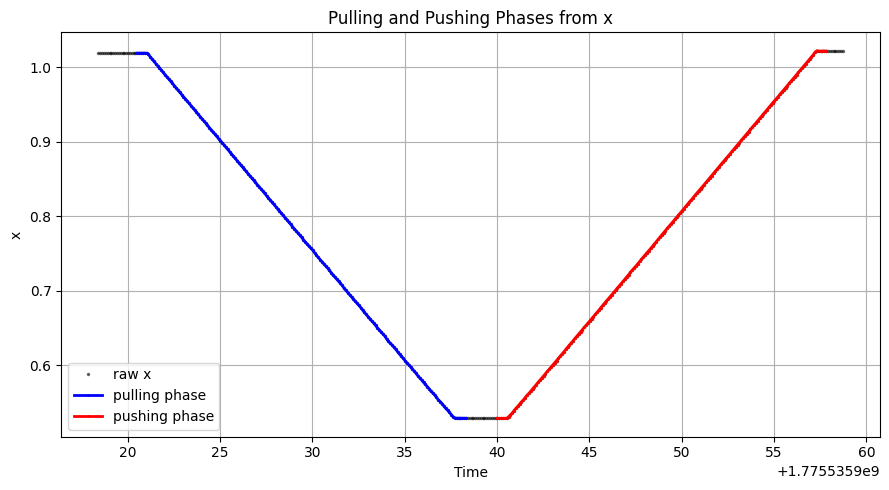

In [2]:
time = data["time"].to_numpy()
x = data["x"].to_numpy()

print("Data loaded. Number of samples:", len(x))

# -----------------------------
# Smooth x to remove tiny noise
# -----------------------------
window = 11   # try 7, 11, or 15
kernel = np.ones(window) / window
x_smooth = np.convolve(x, kernel, mode="same")

# -----------------------------
# Derivative of smoothed x
# -----------------------------
dx = np.diff(x_smooth)

# threshold to ignore tiny slopes
tol = 1e-5

sign = np.zeros_like(dx, dtype=int)
sign[dx < -tol] = -1
sign[dx >  tol] =  1

# -----------------------------
# Helper: find contiguous runs
# -----------------------------
def find_runs(sign_array, target_sign):
    runs = []
    in_run = False
    start = None

    for i, s in enumerate(sign_array):
        if s == target_sign and not in_run:
            start = i
            in_run = True
        elif s != target_sign and in_run:
            runs.append((start, i - 1))
            in_run = False

    if in_run:
        runs.append((start, len(sign_array) - 1))

    return runs

neg_runs = find_runs(sign, -1)
pos_runs = find_runs(sign, +1)

print("Negative runs:", neg_runs)
print("Positive runs:", pos_runs)

if len(neg_runs) == 0:
    raise ValueError("No decreasing run found.")
if len(pos_runs) == 0:
    raise ValueError("No increasing run found.")

# -----------------------------
# Choose the longest decreasing run = pulling
# -----------------------------
neg_lengths = [end - start + 1 for start, end in neg_runs]
pull_run = neg_runs[np.argmax(neg_lengths)]
pull_start, pull_end_diff = pull_run
pull_end = pull_end_diff + 1   # convert diff-index to data-index

# -----------------------------
# Choose the first positive run after pulling = pushing
# or longest positive run after pulling
# -----------------------------
candidate_pos_runs = [run for run in pos_runs if run[0] > pull_end_diff]

if len(candidate_pos_runs) == 0:
    raise ValueError("No increasing run found after pulling phase.")

pos_lengths = [end - start + 1 for start, end in candidate_pos_runs]
push_run = candidate_pos_runs[np.argmax(pos_lengths)]
push_start, push_end_diff = push_run
push_end = push_end_diff + 1

print(f"Pulling phase: start = {pull_start}, end = {pull_end}")
print(f"Pushing phase: start = {push_start}, end = {push_end}")

# -----------------------------
# Extract phases
# -----------------------------
pulling_data = data.iloc[pull_start:pull_end+1].copy()
pushing_data = data.iloc[push_start:push_end+1].copy()

# -----------------------------
# Plot raw and smoothed x
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(time, x, 'k.', markersize=3, alpha=0.5, label="raw x")
# plt.plot(time, x_smooth, 'k-', linewidth=2, label="smoothed x")

plt.plot(time[pull_start:pull_end+1], x[pull_start:pull_end+1],
         'bo-', linewidth=2, markersize=1, label="pulling phase")
plt.plot(time[push_start:push_end+1], x[push_start:push_end+1],
         'ro-', linewidth=2, markersize=1, label="pushing phase")

plt.xlabel("Time")
plt.ylabel("x")
plt.title("Pulling and Pushing Phases from x")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
# extract pulling phase data
pulling_time = pulling_data["time"].to_numpy()
pulling_x = pulling_data["x"].to_numpy()
pulling_F = pulling_data["Fz"].to_numpy()

# extract pushing phase data
pushing_time = pushing_data["time"].to_numpy()
pushing_x = pushing_data["x"].to_numpy()
pushing_F = pushing_data["Fz"].to_numpy()

In [4]:
# shift F by the reference value to make it start at zero
def shift_force_reference(F, idx=0):
    return F - F[idx]

# the displacement x is negative of the actual extension, so we flip its sign, and it should start at reference length
def correct_displacement(x, idx=0, ref_len=0.2):
    x = -x
    # start at 0 by shifting by the initial value
    x = x - x[idx]
    # move the 0th point to the reference length
    x = x + ref_len
    return x

# sort data by increasing x
def sort_by_displacement(x, F):
    sorted_indices = np.argsort(x)
    return x[sorted_indices], F[sorted_indices]

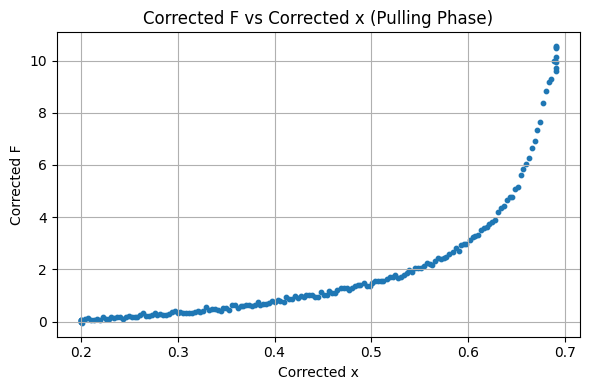

In [5]:

pulling_x_corrected = correct_displacement(pulling_x, ref_len=0.2)
pulling_F_corrected = shift_force_reference(pulling_F)
pulling_x_sorted, pulling_F_sorted = sort_by_displacement(pulling_x_corrected, pulling_F_corrected)

# Plot corrected F vs corrected x for pulling phase
plt.figure(figsize=(6,4))
plt.scatter(pulling_x_sorted, pulling_F_sorted, s=10)
plt.xlabel("Corrected x")
plt.ylabel("Corrected F")
plt.title("Corrected F vs Corrected x (Pulling Phase)")
plt.grid()
plt.tight_layout()
plt.show()


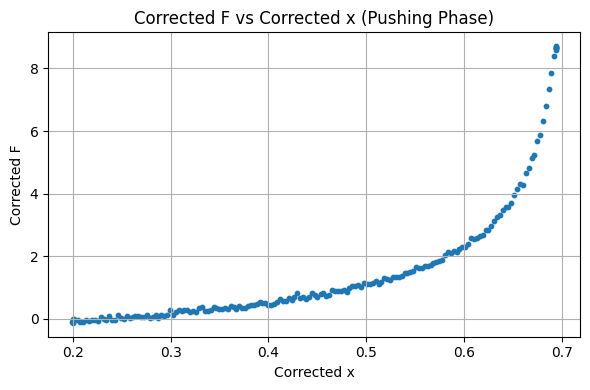

In [6]:
pushing_x_corrected = correct_displacement(pushing_x, ref_len=0.2, idx=-1)
pushing_F_corrected = shift_force_reference(pushing_F, idx=-1)
pushing_x_sorted, pushing_F_sorted = sort_by_displacement(pushing_x_corrected, pushing_F_corrected)
# Plot corrected F vs corrected x for pushing phase
plt.figure(figsize=(6,4))
plt.scatter(pushing_x_sorted, pushing_F_sorted, s=10)
plt.xlabel("Corrected x")
plt.ylabel("Corrected F")
plt.title("Corrected F vs Corrected x (Pushing Phase)")
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
# save data for training
# We need the following for training:
# force_truth = jnp.array(data["F"])         # shape (N,)
# disps = jnp.array(data["disps"])           # exact pulled-node positions
# initial_last_node_x = float(data["initial_last_node_x"])

# pulling phase data
save_file = "pulling_phase_data.npz"
np.savez(
        save_file,
        F=pulling_F_sorted,
        disps=pulling_x_sorted,
        initial_last_node_x=float(pulling_x_sorted[0])
    )

# pushing phase data
save_file = "pushing_phase_data.npz"
np.savez(
        save_file,
        F=pushing_F_sorted,
        disps=pushing_x_sorted,
        initial_last_node_x=float(pushing_x_sorted[0])
    )